In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster
from src.datasets import MaterialsProject
from src.outliers.outlier_detection import hdbscan_outliers, knn_outliers, lof_outliers
from src.outliers.eval_outlier_results import plot_score_distributions, evaluate_outlier_methods

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
# def keep_outliers(outliers_df, n):
#     # determines how many too keep of each
#     return outliers_df.group_by("outlier_category", maintain_order=True).head(n)
    
outliers = pl.read_parquet('data/Materials Project/outliers/synthetic_materials_outliers.parquet')
#outliers = keep_outliers(outliers, 5)
outliers

material_id,formula_pretty,anonymized_formula,structural_prototype,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,pearson_symbol,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,outlier_category,is_injected
str,str,str,str,f64,f64,f64,f64,bool,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,str,i64
"""synthetic-size_outliers-Si""","""Si""","""A""","""A_cF8_Fd-3m_a""",0.0,0.0,0.0,1.1,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Fd-3m""","""cF8""",2.330353,16.29,16.29,16.29,90.0,90.0,90.0,4322.781189,216,0.0,2.351259,2.351259,"""size_outliers""",1
"""synthetic-element_outliers-Xe""","""Xe""","""A""","""A_cF4_Fm-3m_a""",0.0,0.0,0.0,9.3,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Fm-3m""","""cF4""",3.659111,6.2,6.2,6.2,90.0,90.0,90.0,238.328,4,0.0,4.384062,4.384062,"""element_outliers""",1
"""synthetic-element_outliers-U""","""U""","""A""","""A_cI2_Im-3m_a""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Im-3m""","""cI2""",18.757332,3.48,3.48,3.48,90.0,90.0,90.0,42.144192,2,0.0,3.013768,3.013768,"""element_outliers""",1
"""synthetic-element_outliers-H4C""","""H4C""","""AB4""","""AB4_cP5_P-43m_a_e""",0.35,0.0,0.0,6.0,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""P-43m""","""cP5""",0.136533,5.8,5.8,5.8,90.0,90.0,90.0,195.112,5,0.0,1.004589,1.004589,"""element_outliers""",1
"""synthetic-topology_outliers-C""","""C""","""A""","""A_hP2_P6/mmm_c""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""hexagonal""","""P6/mmm""","""hP2""",0.152222,2.46,2.46,50.0,90.0,90.0,120.0,262.041967,2,0.0,1.420282,1.420282,"""topology_outliers""",1
"""synthetic-topology_outliers-Fe""","""Fe""","""A""","""A_cP1_Pm-3m_a""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Pm-3m""","""cP1""",0.011592,20.0,20.0,20.0,90.0,90.0,90.0,8000.0,1,0.0,null,null,"""topology_outliers""",1
"""synthetic-topology_outliers-Fe""","""Fe""","""A""","""A_cI2_Im-3m_a""",0.0,0.0,0.0,0.0,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Im-3m""","""cI2""",107.329635,1.2,1.2,1.2,90.0,90.0,90.0,1.728,2,50.0,1.03923,1.03923,"""topology_outliers""",1
"""synthetic-extreme_outliers-MnC…","""MnCrFeCoNi""","""ABCDE""","""ABCDE_oP5_Pmmm_a_d_f_g_h""",0.36,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""orthorhombic""","""Pmmm""","""oP5""",7.275386,4.0,4.0,4.0,90.0,90.0,90.0,64.0,5,0.0,2.165685,2.828427,"""extreme_outliers""",1


In [4]:
descriptor = "soap"

mp = MaterialsProject(limit=5000, 
                 sampling_strategy="stratified",
                 stratify_on=["energy_above_hull", "band_gap"], 
                 injected_materials = outliers,
                 descriptors=[descriptor],
                 )
df = mp.load()

2026-04-24 13:28:36.738 | INFO     | src.datasets:load:1814 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-24 13:28:37.544 | INFO     | src.datasets:inject_outliers:1799 - Injected custom outliers into Materials Project dataframe: requested=8, total_rows=6008.
2026-04-24 13:28:37.544 | INFO     | src.datasets:_add_descriptors:2187 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-24 13:28:37.544 | INFO     | src.datasets:_add_descriptors:2191 - Extracting unique elements from formulas...
2026-04-24 13:28:51.601 | INFO     | src.datasets:_add_descriptors:2200 - Found 86 unique elements.
2026-04-24 13:28:51.603 | INFO     | src.datasets:_add_descriptors:2245 - Computing SOAP chunk 0 (0 to 1000)...
2026-04-24 13:28:53.268 | INFO     | src.datasets:_add_descriptors:2245 - Computing SOAP chunk 1 (1000 to 2000)...
2026-04-24 13:28:55.078 | INFO     | src.datasets:_add_descriptors:224

In [5]:
df.filter(pl.col(['is_injected']) ==1)

material_id,formula_pretty,anonymized_formula,structural_prototype,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,pearson_symbol,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,is_injected,outlier_category,soap_embedding
str,str,str,str,f64,f64,f64,f64,bool,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,str,list[f64]
"""synthetic-size_outliers-Si""","""Si""","""A""","""A_cF8_Fd-3m_a""",0.0,0.0,0.0,1.1,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Fd-3m""","""cF8""",2.330353,16.29,16.29,16.29,90.0,90.0,90.0,4322.781189,216,0.0,2.351259,2.351259,1,"""size_outliers""","[43.059904, 127.767287, … 291.957891]"
"""synthetic-element_outliers-Xe""","""Xe""","""A""","""A_cF4_Fm-3m_a""",0.0,0.0,0.0,9.3,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Fm-3m""","""cF4""",3.659111,6.2,6.2,6.2,90.0,90.0,90.0,238.328,4,0.0,4.384062,4.384062,1,"""element_outliers""","[676.064503, 1873.358708, … 2637.297062]"
"""synthetic-element_outliers-U""","""U""","""A""","""A_cI2_Im-3m_a""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Im-3m""","""cI2""",18.757332,3.48,3.48,3.48,90.0,90.0,90.0,42.144192,2,0.0,3.013768,3.013768,1,"""element_outliers""","[1990.909927, 5502.410825, … 57445.105476]"
"""synthetic-element_outliers-H4C""","""H4C""","""AB4""","""AB4_cP5_P-43m_a_e""",0.35,0.0,0.0,6.0,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""P-43m""","""cP5""",0.136533,5.8,5.8,5.8,90.0,90.0,90.0,195.112,5,0.0,1.004589,1.004589,1,"""element_outliers""","[0.664504, 2.153371, … 0.004629]"
"""synthetic-topology_outliers-C""","""C""","""A""","""A_hP2_P6/mmm_c""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""hexagonal""","""P6/mmm""","""hP2""",0.152222,2.46,2.46,50.0,90.0,90.0,120.0,262.041967,2,0.0,1.420282,1.420282,1,"""topology_outliers""","[6.824834, 16.207707, … 154.932599]"
"""synthetic-topology_outliers-Fe""","""Fe""","""A""","""A_cP1_Pm-3m_a""",0.0,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Pm-3m""","""cP1""",0.011592,20.0,20.0,20.0,90.0,90.0,90.0,8000.0,1,0.0,null,null,1,"""topology_outliers""","[157.113785, 435.17624, … 0.0]"
"""synthetic-topology_outliers-Fe""","""Fe""","""A""","""A_cI2_Im-3m_a""",0.0,0.0,0.0,0.0,false,"""{""@module"": ""pymatgen.core.str…","""cubic""","""Im-3m""","""cI2""",107.329635,1.2,1.2,1.2,90.0,90.0,90.0,1.728,2,50.0,1.03923,1.03923,1,"""topology_outliers""","[2.756493, -22.613919, … 9.7012e-8]"
"""synthetic-extreme_outliers-MnC…","""MnCrFeCoNi""","""ABCDE""","""ABCDE_oP5_Pmmm_a_d_f_g_h""",0.36,0.0,0.0,0.0,true,"""{""@module"": ""pymatgen.core.str…","""orthorhombic""","""Pmmm""","""oP5""",7.275386,4.0,4.0,4.0,90.0,90.0,90.0,64.0,5,0.0,2.165685,2.828427,1,"""extreme_outliers""","[155.112194, 432.034116, … 602.098727]"


In [6]:
if descriptor == "soap":
    dist_matrix = mp.get_distance_matrix(descriptor, "soap_kernel",force_calculate=True)
elif descriptor in ["morgan", "onehot"]:
    dist_matrix = mp.get_distance_matrix(descriptor, "jaccard",force_calculate=True)
else:
    dist_matrix = mp.get_distance_matrix(descriptor, "euclidean",force_calculate=True)

2026-04-24 13:29:05.202 | INFO     | src.datasets:get_distance_matrix:2504 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-24 13:29:05.652 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/Materials Project/dist_soap_soap_kernel.npy


In [7]:
df = hdbscan_outliers(df, dist_matrix)
df = knn_outliers(df, dist_matrix)
df = lof_outliers(df, dist_matrix)

Starting HDBSCAN Auto-Tuning over 125 combinations for N=5008...


🔍 Evaluating HDBSCAN: 100%|██████████| 125/125 [01:03<00:00,  1.98cfg/s, mcs=500, ms=500, clusters=0]



--- Auto-Tuning Results ---
Selected params: min_cluster_size=34, min_samples=1
Metrics: clusters=3, noise=0.1597, persistence=0.039
HDBSCAN — 4 distinct labels: -1: 800, 0: 45, 1: 4105, 2: 58
k-NN — 2 distinct: -1: 501, 1: 4507
LOF — 2 distinct: -1: 251, 1: 4757


In [8]:
results = evaluate_outlier_methods(df, ["hdbscan", "knn", "lof"])
results

Method,Global_Recall,False_Positive_Rate,Flagged_QM9_Count,Total_Flagged,Total_Missed,ROC_AUC,Recall: size_outliers,Recall: extreme_outliers,Recall: topology_outliers,Recall: element_outliers
str,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64
"""HDBSCAN""",0.75,0.1588,794,6,2,0.83,1.0,0.0,1.0,0.667
"""KNN""",0.625,0.0992,496,5,3,0.815,0.0,0.0,1.0,0.667
"""LOF""",0.625,0.0492,246,5,3,0.831,0.0,0.0,1.0,0.667


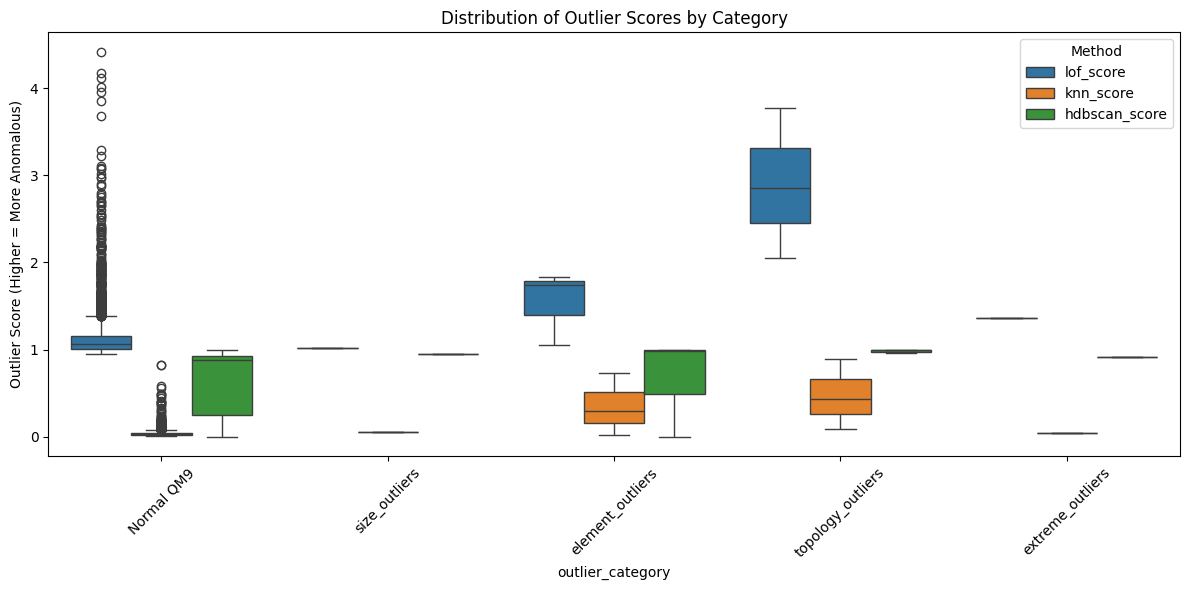

In [9]:
plot_score_distributions(df)

In [10]:
def append_outlier_consensus(df: pl.DataFrame) -> pl.DataFrame:
    """Calculates outlier consensus and creates categorical strings for Chemiscope visualization."""
    models = ["hdbscan", "knn", "lof"]
    cols_to_add = []
    vote_cols = []
    
    for model in models:
        col_name = f"{model}_label"
        if col_name in df.columns:
            # 1. Create binary flag for voting (1 = outlier, 0 = inlier)
            vote_col = f"is_{model}_outlier"
            cols_to_add.append((pl.col(col_name) == -1).cast(pl.Int8).alias(vote_col))
            vote_cols.append(pl.col(vote_col))
            
            # 2. Create readable string category for individual viewing
            cols_to_add.append(
                pl.when(pl.col(col_name) == -1).then(pl.lit("Outlier"))
                .otherwise(pl.lit("Inlier"))
                .alias(f"{model}_category")
            )
            
    df_out = df.with_columns(cols_to_add)
    
    # 3. Calculate total votes and map to color categories
    if vote_cols:
        df_out = df_out.with_columns(pl.sum_horizontal(vote_cols).alias("outlier_votes"))
        
        df_out = df_out.with_columns(
            pl.when(pl.col("outlier_votes") == 3).then(pl.lit("3: Consensus Outlier"))
            .when(pl.col("outlier_votes") == 2).then(pl.lit("2: Strong Outlier"))
            .when(pl.col("outlier_votes") == 1).then(pl.lit("1: Weak Outlier"))
            .otherwise(pl.lit("0: Inlier"))
            .alias("Consensus_Category")
        )
        
    return df_out

df_for_viewer = append_outlier_consensus(df)

In [11]:
df_for_viewer = append_outlier_consensus(df)
create_chemiscope_viewer(df_for_viewer, dist_matrix, df_for_viewer['is_injected'].to_numpy(), 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/chemiscope/input.py:347: UserWarning: Property 'avg_bond_length' has NaNs. If it is selected for display, the corresponding points will be hidden from the map
  properties = _expand_properties(properties, n_structures, n_atoms)
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/chemiscope/input.py:347: UserWarning: Property 'max_bond_length' has NaNs. If it is selected for display, the corresponding points will be hidden from the map
  properties = _expand_properties(properties, n_structures, n_atoms)


Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…